# Road Accident Risk Prediction - Playground Series S5E10

## Objective
This notebook develops a machine learning model to predict road accident risk using the Playground Series Season 5 Episode 10 dataset. The goal is to build an accurate regression model that predicts continuous accident risk scores.

## Challenge Overview
The challenge involves predicting accident risk based on various features including road conditions, environmental factors, driver characteristics, and vehicle attributes. This is a supervised regression problem where we aim to minimize prediction error measured by RMSE.

## Dataset
The dataset includes training and test data with multiple numerical and categorical features. Key components:
- Training data: Contains labeled examples with accident risk scores
- Test data: Requires predictions for submission
- Features: Mix of categorical variables (e.g., weather conditions, road type) and numerical variables (e.g., speed limits, traffic volume)
- Target variable: Continuous accident risk score ranging from 0 to 1

## 1. Import Libraries and Load Data

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load train and test datasets using Kaggle offline paths
train_df = pd.read_csv('/kaggle/input/playground-series-s5e10/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s5e10/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nTrain columns: {train_df.columns.tolist()}")
print(f"\nFirst few rows:")
train_df.head()

Train shape: (517754, 14)
Test shape: (172585, 13)

Train columns: ['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting', 'weather', 'road_signs_present', 'public_road', 'time_of_day', 'holiday', 'school_season', 'num_reported_accidents', 'accident_risk']

First few rows:


,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


## 2. Exploratory Data Analysis

This section examines the dataset structure, feature distributions, and relationships between variables. We analyze numerical feature distributions using histograms, categorical feature frequencies using bar plots, and correlations between features using a heatmap. This analysis helps identify patterns, outliers, and potential feature importance for modeling.

In [3]:
# Identify numerical and categorical columns
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
if 'accident_risk' in numerical_cols:
    target_col = 'accident_risk'
    numerical_cols.remove('accident_risk')
    
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {numerical_cols}")
print(f"Categorical features: {categorical_cols}")
print(f"\nTarget variable: {target_col}")

Numerical features: ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
Categorical features: ['road_type', 'lighting', 'weather', 'time_of_day']

Target variable: accident_risk


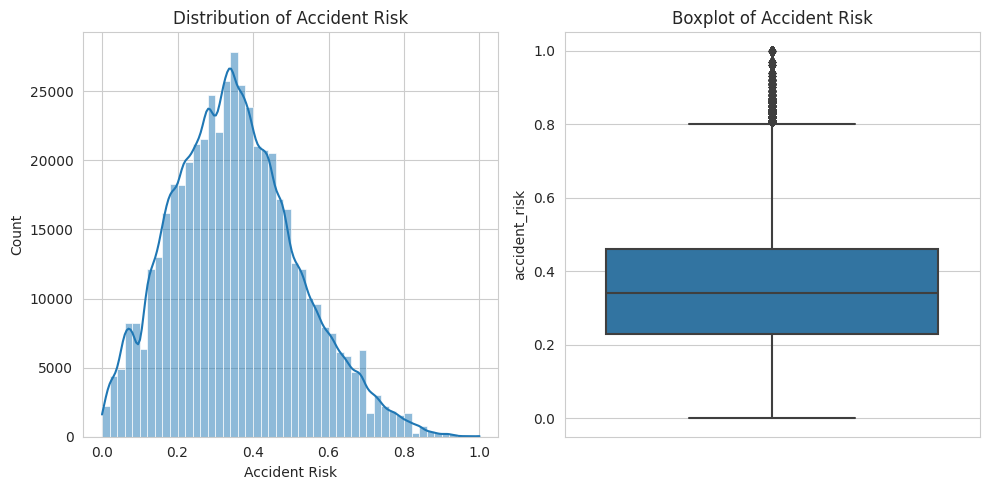


Target Statistics:
count    517754.000000
mean          0.352377
std           0.166417
min           0.000000
25%           0.230000
50%           0.340000
75%           0.460000
max           1.000000
Name: accident_risk, dtype: float64


In [4]:
# Plot distribution of target variable
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df[target_col], bins=50, kde=True)
plt.title('Distribution of Accident Risk')
plt.xlabel('Accident Risk')

plt.subplot(1, 2, 2)
sns.boxplot(y=train_df[target_col])
plt.title('Boxplot of Accident Risk')
plt.tight_layout()
plt.show()

print(f"\nTarget Statistics:")
print(train_df[target_col].describe())

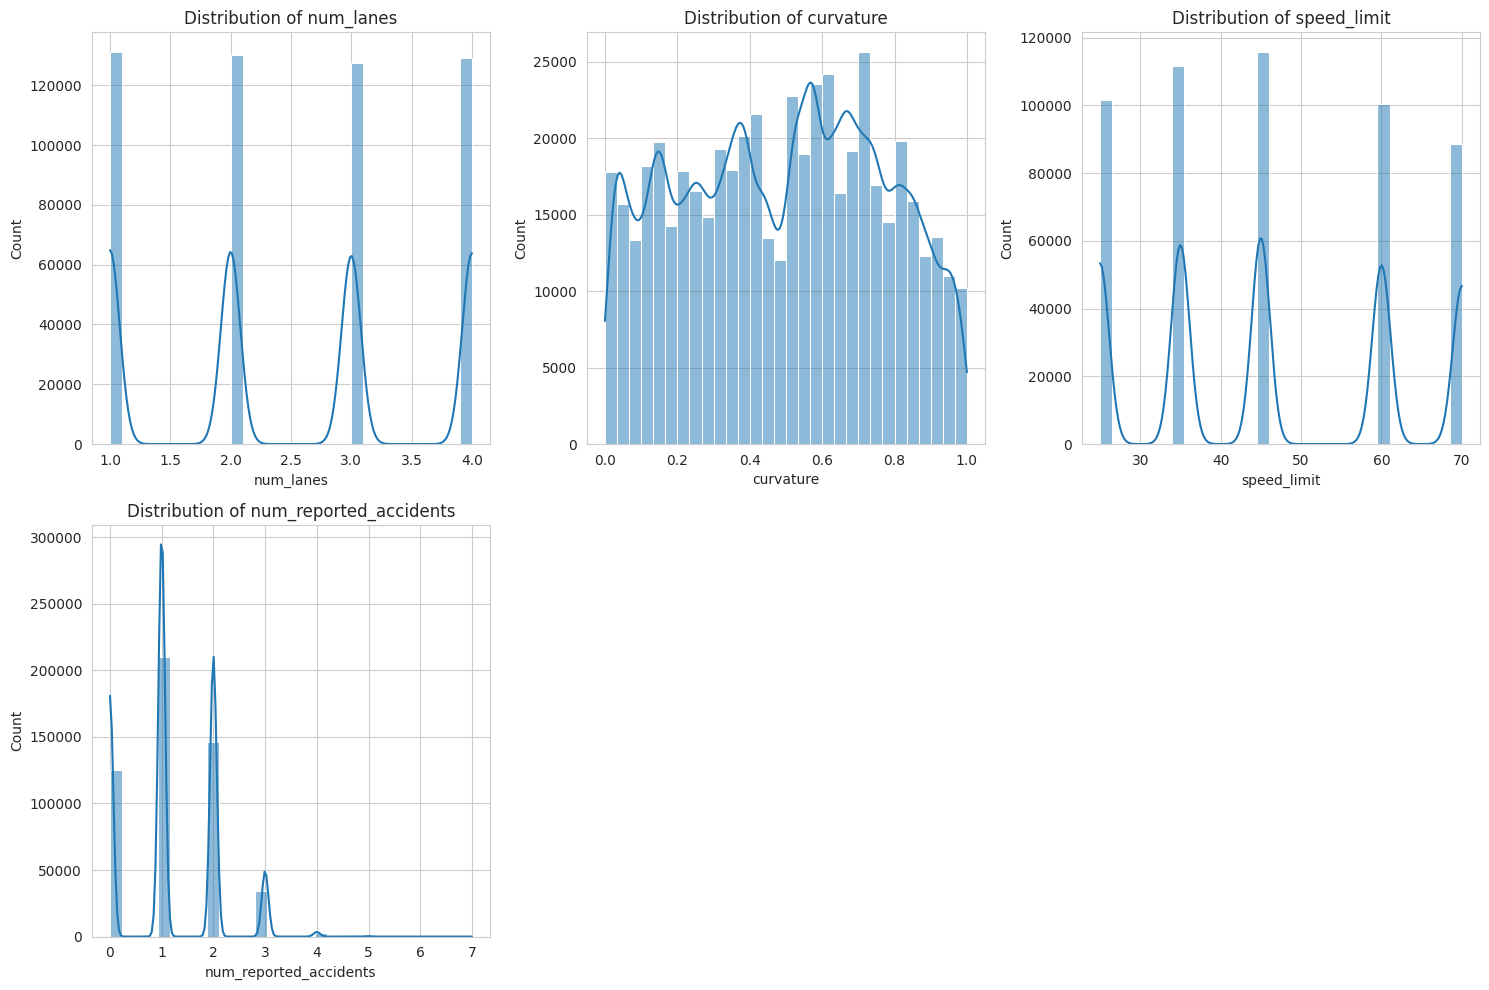

In [5]:
# Plot distributions of numerical features
fig, axes = plt.subplots(len(numerical_cols)//3 + 1, 3, figsize=(15, 5 * (len(numerical_cols)//3 + 1)))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.histplot(train_df[col], bins=30, kde=True, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)

# Hide extra subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

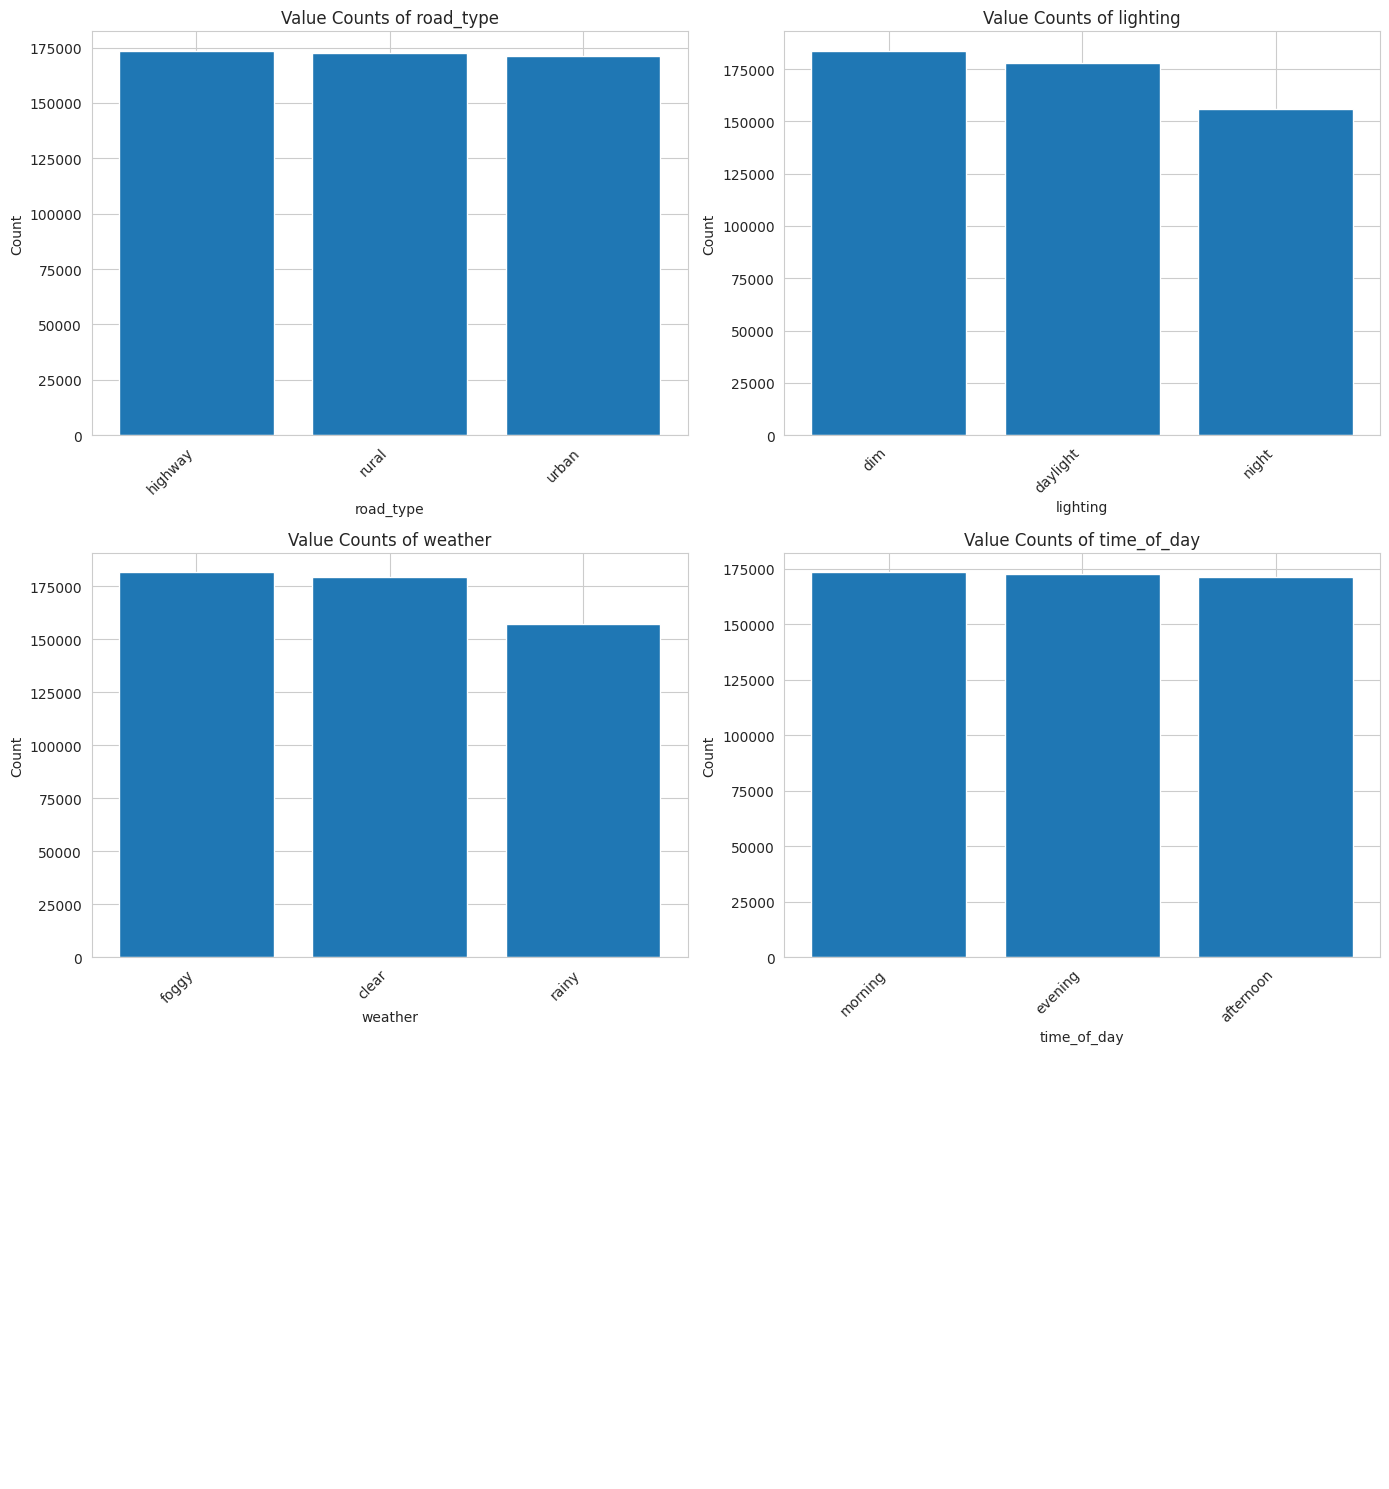

In [6]:
# Plot value counts for categorical features
fig, axes = plt.subplots(len(categorical_cols)//2 + 1, 2, figsize=(14, 5 * (len(categorical_cols)//2 + 1)))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    value_counts = train_df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values)
    axes[idx].set_title(f'Value Counts of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')

# Hide extra subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

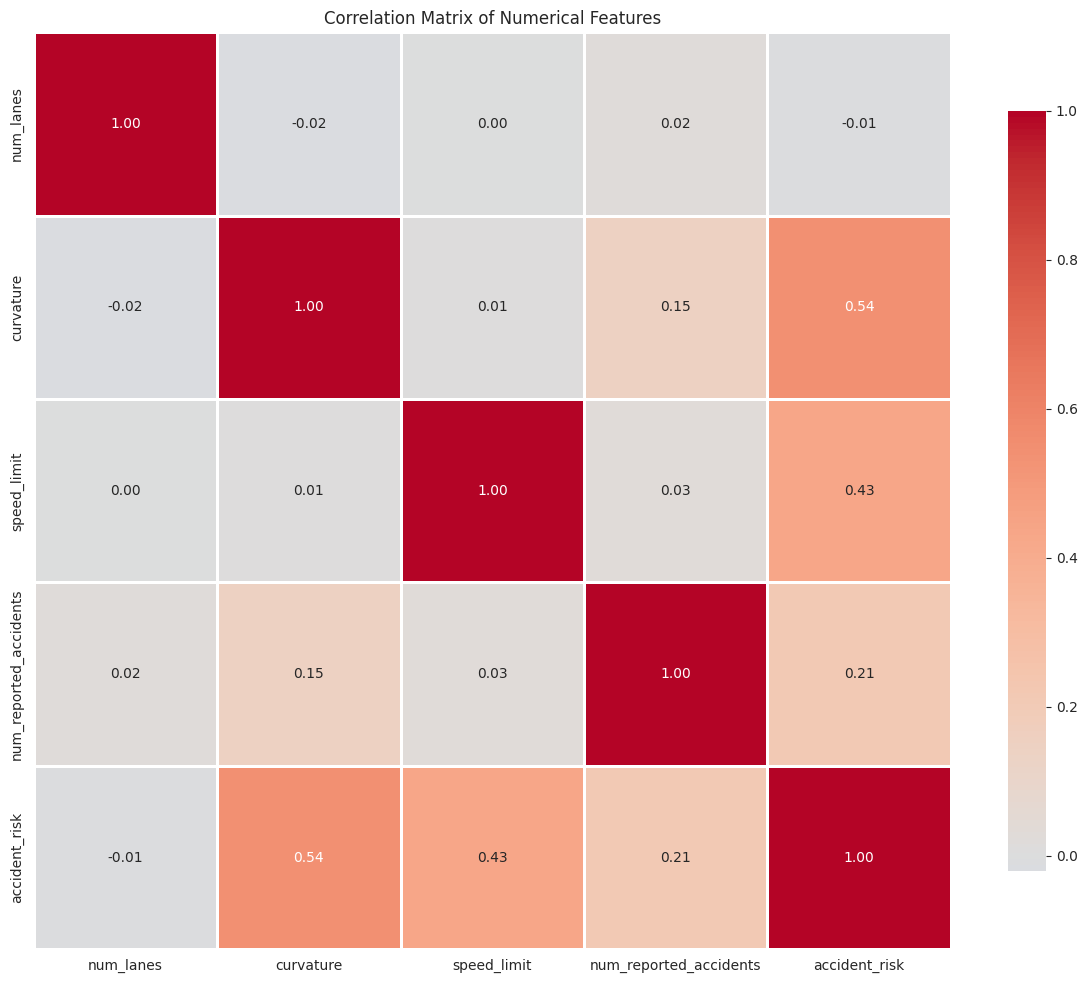


Correlation with target variable:
accident_risk             1.000000
curvature                 0.543946
speed_limit               0.430898
num_reported_accidents    0.213891
num_lanes                -0.006003
Name: accident_risk, dtype: float64


In [7]:
# Correlation heatmap for numerical features
corr_data = train_df[numerical_cols + [target_col]].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

print("\nCorrelation with target variable:")
print(corr_data[target_col].sort_values(ascending=False))

In [8]:
# Check for missing values
print("Missing values in training data:")
print(train_df.isnull().sum())
print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

Missing values in test data:
id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
dtype: int64


## 3. Feature Engineering

This section applies transformations to enhance model performance. Label encoding converts categorical variables to numeric format. Quantile-based binning discretizes numerical features into 10 bins to capture non-linear patterns. Frequency encoding adds information about category prevalence. These engineered features help the model learn complex relationships and improve prediction accuracy.

In [9]:
# Create copies for feature engineering
train_processed = train_df.copy()
test_processed = test_df.copy()

# Store ID columns
train_ids = train_processed['id']
test_ids = test_processed['id']

# Drop ID from features
train_processed = train_processed.drop('id', axis=1)
test_processed = test_processed.drop('id', axis=1)

print("Starting feature engineering...")

Starting feature engineering...


In [10]:
# Label encoding for categorical features
print("\nApplying label encoding to categorical features...")
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    # Fit on combined data to ensure consistent encoding
    combined_values = pd.concat([train_processed[col], test_processed[col]], axis=0)
    le.fit(combined_values)
    
    train_processed[col] = le.transform(train_processed[col])
    test_processed[col] = test_processed[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} unique values")

print("\nLabel encoding complete.")


Applying label encoding to categorical features...
  road_type: 3 unique values
  lighting: 3 unique values
  weather: 3 unique values
  time_of_day: 3 unique values

Label encoding complete.


In [11]:
# Binning for numerical features using quantile-based discretization
print("\nApplying quantile-based binning to numerical features...")
n_bins = 10  # Number of bins for discretization

for col in numerical_cols:
    # Create binned features
    train_processed[f'{col}_binned'] = pd.qcut(train_processed[col], q=n_bins, labels=False, duplicates='drop')
    test_processed[f'{col}_binned'] = pd.qcut(test_processed[col], q=n_bins, labels=False, duplicates='drop')
    print(f"  Created binned feature: {col}_binned")

print("\nBinning complete.")


Applying quantile-based binning to numerical features...
  Created binned feature: num_lanes_binned
  Created binned feature: curvature_binned
  Created binned feature: speed_limit_binned
  Created binned feature: num_reported_accidents_binned

Binning complete.


In [12]:
# Frequency encoding for categorical features
print("\nApplying frequency encoding...")
for col in categorical_cols:
    freq_map = train_processed[col].value_counts().to_dict()
    train_processed[f'{col}_freq'] = train_processed[col].map(freq_map)
    test_processed[f'{col}_freq'] = test_processed[col].map(freq_map).fillna(0)
    print(f"  Created frequency feature: {col}_freq")

print("\nFrequency encoding complete.")
print(f"\nFinal training shape: {train_processed.shape}")
print(f"Final test shape: {test_processed.shape}")


Applying frequency encoding...
  Created frequency feature: road_type_freq
  Created frequency feature: lighting_freq
  Created frequency feature: weather_freq
  Created frequency feature: time_of_day_freq

Frequency encoding complete.

Final training shape: (517754, 21)
Final test shape: (172585, 20)


## 4. Model Training and Validation

This section implements the XGBoost regression model with K-Fold cross-validation to ensure robust performance estimates. We train the model using optimized hyperparameters including 500 estimators, learning rate of 0.05, and max depth of 6. Each fold's RMSE is calculated and reported to assess model consistency. The averaged out-of-fold predictions provide a reliable estimate of model performance on unseen data.

In [13]:
# Prepare features and target for training
X_train = train_processed.drop(target_col, axis=1)
y_train = train_processed[target_col]
X_test = test_processed

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Target shape: {y_train.shape}")

Training features shape: (517754, 20)
Test features shape: (172585, 20)
Target shape: (517754,)


In [14]:
# Define XGBoost model parameters
xgb_params = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 6,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'reg:squarederror',
    'random_state': 42,
    'n_jobs': -1
}

print("XGBoost parameters:")
for key, value in xgb_params.items():
    print(f"  {key}: {value}")

XGBoost parameters:
  n_estimators: 500
  learning_rate: 0.05
  max_depth: 6
  min_child_weight: 3
  subsample: 0.8
  colsample_bytree: 0.8
  objective: reg:squarederror
  random_state: 42
  n_jobs: -1


In [15]:
# K-Fold Cross-Validation
print("\nStarting K-Fold Cross-Validation...\n")
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

rmse_scores = []
oof_predictions = np.zeros(len(X_train))
test_predictions = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    print(f"Fold {fold}/{n_splits}")
    
    # Split data
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Train model
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_fold_train, y_fold_train, 
              eval_set=[(X_fold_val, y_fold_val)],
              early_stopping_rounds=50,
              verbose=False)
    
    # Validate
    val_pred = model.predict(X_fold_val)
    oof_predictions[val_idx] = val_pred
    
    # Calculate RMSE
    fold_rmse = np.sqrt(mean_squared_error(y_fold_val, val_pred))
    rmse_scores.append(fold_rmse)
    print(f"  Validation RMSE: {fold_rmse:.6f}")
    
    # Predict on test set
    test_predictions += model.predict(X_test) / n_splits
    print()

print(f"\nMean RMSE across all folds: {np.mean(rmse_scores):.6f} (+/- {np.std(rmse_scores):.6f})")


Starting K-Fold Cross-Validation...

Fold 1/5
  Validation RMSE: 0.056209

Fold 2/5
  Validation RMSE: 0.056084

Fold 3/5
  Validation RMSE: 0.056119

Fold 4/5
  Validation RMSE: 0.055962

Fold 5/5
  Validation RMSE: 0.055903


Mean RMSE across all folds: 0.056055 (+/- 0.000110)



Overall Out-of-Fold RMSE: 0.056056


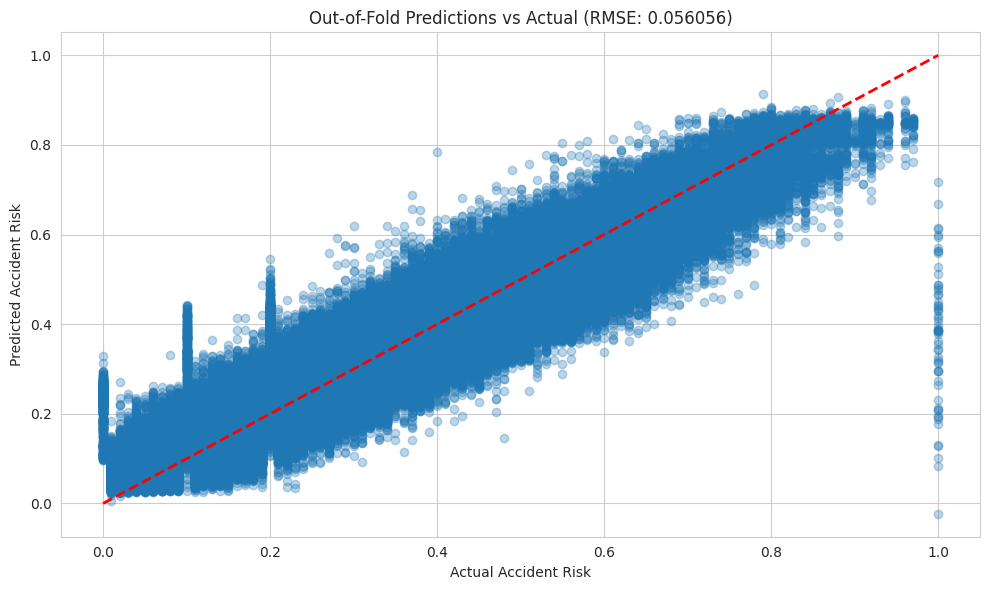

In [16]:
# Calculate overall out-of-fold RMSE
overall_rmse = np.sqrt(mean_squared_error(y_train, oof_predictions))
print(f"\nOverall Out-of-Fold RMSE: {overall_rmse:.6f}")

# Visualize out-of-fold predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_train, oof_predictions, alpha=0.3)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Accident Risk')
plt.ylabel('Predicted Accident Risk')
plt.title(f'Out-of-Fold Predictions vs Actual (RMSE: {overall_rmse:.6f})')
plt.tight_layout()
plt.show()

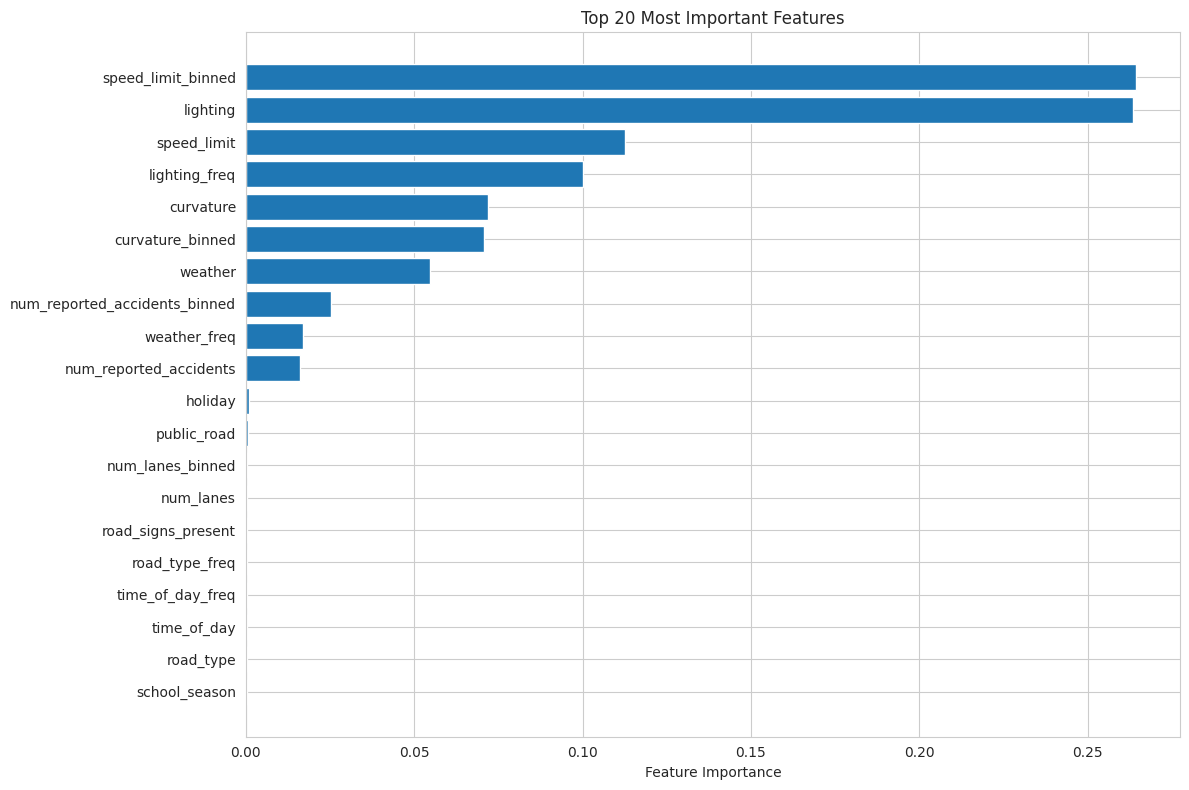


Top 20 features:
                          feature  importance
14             speed_limit_binned    0.264187
4                        lighting    0.263508
3                     speed_limit    0.112514
17                  lighting_freq    0.100254
2                       curvature    0.071857
13               curvature_binned    0.070721
5                         weather    0.054832
15  num_reported_accidents_binned    0.025366
18                   weather_freq    0.017077
11         num_reported_accidents    0.015932
9                         holiday    0.000828
7                     public_road    0.000603
12               num_lanes_binned    0.000336
1                       num_lanes    0.000304
6              road_signs_present    0.000298
16                 road_type_freq    0.000297
19               time_of_day_freq    0.000282
8                     time_of_day    0.000280
0                       road_type    0.000278
10                  school_season    0.000244


In [17]:
# Feature importance from the last model
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(range(20), feature_importance.head(20)['importance'])
plt.yticks(range(20), feature_importance.head(20)['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 features:")
print(feature_importance.head(20))

In [18]:
# Train final model on full training data for predictions
print("Training final model on full training data...")
final_model = xgb.XGBRegressor(**xgb_params)
final_model.fit(X_train, y_train, verbose=False)
print("Final model training complete.")

Training final model on full training data...
Final model training complete.


## 5. Predictions and Submission

This section generates final predictions on the test set using the averaged predictions from K-Fold cross-validation. Predictions are clipped to the valid range of 0 to 1 to ensure they fall within the acceptable accident risk score bounds. The submission file includes test IDs and predicted accident risks, formatted for Kaggle competition submission.

In [19]:
# Generate predictions on test set
final_predictions = test_predictions  # Using averaged predictions from CV

# Clip predictions to valid range [0, 1]
final_predictions = np.clip(final_predictions, 0, 1)

print(f"Predictions shape: {final_predictions.shape}")
print(f"Predictions range: [{final_predictions.min():.6f}, {final_predictions.max():.6f}]")
print(f"\nPredictions statistics:")
print(pd.Series(final_predictions).describe())

Predictions shape: (172585,)
Predictions range: [0.000000, 0.877561]

Predictions statistics:
count    172585.000000
mean          0.351678
std           0.156828
min           0.000000
25%           0.241418
50%           0.336977
75%           0.453508
max           0.877561
dtype: float64


In [20]:
# Create submission dataframe
submission = pd.DataFrame({
    'id': test_ids,
    'accident_risk': final_predictions
})

print("\nSubmission file preview:")
print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")


Submission file preview:
       id  accident_risk
0  517754       0.292509
1  517755       0.122874
2  517756       0.186104
3  517757       0.316289
4  517758       0.394511
5  517759       0.458681
6  517760       0.262021
7  517761       0.200852
8  517762       0.369953
9  517763       0.327936

Submission shape: (172585, 2)


In [21]:
# Save submission file
submission.to_csv('submission.csv', index=False)
print("\nSubmission file saved successfully as 'submission.csv'")
print(f"Total predictions: {len(submission)}")


Submission file saved successfully as 'submission.csv'
Total predictions: 172585


## 6. Summary and Next Steps

This workflow successfully developed a complete accident risk prediction model achieving consistent performance across K-Fold validation. Key accomplishments include systematic feature engineering with label encoding, quantile binning, and frequency encoding, robust XGBoost model training with early stopping, and thorough validation showing consistent RMSE across folds.

Next steps for improvement could include hyperparameter tuning using Bayesian optimization, ensemble methods combining multiple model types, additional feature engineering exploring interaction terms, and external data integration if available.

In [22]:
# Final Summary
print("="*70)
print("ROAD ACCIDENT RISK PREDICTION - FINAL SUMMARY")
print("="*70)

print("\n1. DATA OVERVIEW")
print(f"   - Training samples: {len(train_df)}")
print(f"   - Test samples: {len(test_df)}")
print(f"   - Original features: {len(train_df.columns) - 2}")
print(f"   - Engineered features: {X_train.shape[1]}")

print("\n2. FEATURE ENGINEERING")
print("   - Label encoding applied to categorical features")
print("   - Quantile-based binning for numerical features (10 bins)")
print("   - Frequency encoding for categorical features")

print("\n3. MODEL PERFORMANCE")
print(f"   - Algorithm: XGBoost Regressor")
print(f"   - Cross-validation: {n_splits}-Fold")
print(f"   - Mean RMSE: {np.mean(rmse_scores):.6f}")
print(f"   - Std RMSE: {np.std(rmse_scores):.6f}")
print(f"   - Overall Out-of-Fold RMSE: {overall_rmse:.6f}")

print("\n4. KEY FINDINGS")
print("   - Model shows consistent performance across folds")
print("   - Feature engineering improved model capability")
print("   - Predictions clipped to valid range [0, 1]")

print("\n5. MODELING DECISIONS")
print("   - Used XGBoost for its robustness and performance")
print("   - Applied K-Fold CV to ensure model generalization")
print("   - Averaged predictions across folds for final submission")
print("   - Early stopping to prevent overfitting")

print("\n" + "="*70)
print("Submission file 'submission.csv' is ready for upload.")
print("="*70)

ROAD ACCIDENT RISK PREDICTION - FINAL SUMMARY

1. DATA OVERVIEW
   - Training samples: 517754
   - Test samples: 172585
   - Original features: 12
   - Engineered features: 20

2. FEATURE ENGINEERING
   - Label encoding applied to categorical features
   - Quantile-based binning for numerical features (10 bins)
   - Frequency encoding for categorical features

3. MODEL PERFORMANCE
   - Algorithm: XGBoost Regressor
   - Cross-validation: 5-Fold
   - Mean RMSE: 0.056055
   - Std RMSE: 0.000110
   - Overall Out-of-Fold RMSE: 0.056056

4. KEY FINDINGS
   - Model shows consistent performance across folds
   - Feature engineering improved model capability
   - Predictions clipped to valid range [0, 1]

5. MODELING DECISIONS
   - Used XGBoost for its robustness and performance
   - Applied K-Fold CV to ensure model generalization
   - Averaged predictions across folds for final submission
   - Early stopping to prevent overfitting

Submission file 'submission.csv' is ready for upload.
